# 01 · Exploration de TrashNet (classification)

Objectif : connaître le dataset avant d'entraîner le CNN.
Questions : combien d'images par classe ? quelles tailles ? le fond est-il toujours blanc ? y a-t-il des doublons ?

In [1]:
# Cellule 1 : imports et chemins
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# On remonte jusqu'au dossier du projet (celui qui contient "ml"), où que soit lancé le notebook
ROOT = Path.cwd()
while not (ROOT / "ml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA = ROOT / "ml" / "data" / "raw" / "trashnet"
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("Projet  :", ROOT)
print("Données :", DATA, "->", "OK" if DATA.exists() else "INTROUVABLE")
print("Contenu :", sorted(p.name for p in DATA.iterdir()))

Projet  : c:\waste-sorting-mlops
Données : c:\waste-sorting-mlops\ml\data\raw\trashnet -> OK
Contenu : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [2]:
# Cellule 2 : liste de toutes les images (une ligne par image)
EXTS = {".jpg", ".jpeg", ".png"}
classes = sorted(p.name for p in DATA.iterdir() if p.is_dir())

rows = []
for c in classes:
    for f in sorted((DATA / c).iterdir()):
        if f.suffix.lower() in EXTS:
            rows.append({"classe": c, "fichier": f.name, "chemin": f})
df = pd.DataFrame(rows)

ignores = [p.name for p in DATA.rglob("*") if p.is_file() and p.suffix.lower() not in EXTS]
print(f"{len(df)} images, {len(classes)} classes : {classes}")
print("Fichiers ignorés (pas des images) :", ignores)

2527 images, 6 classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Fichiers ignorés (pas des images) : []


,images,%
classe,,
cardboard,403,15.9
glass,501,19.8
metal,410,16.2
paper,594,23.5
plastic,482,19.1
trash,137,5.4


Rapport plus grande / plus petite classe : 4.3


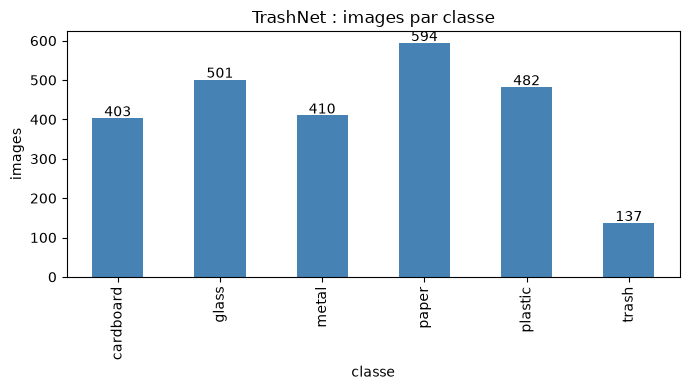

In [3]:
# Cellule 3 : nombre d'images par classe -> déséquilibre ?
compte = df["classe"].value_counts().sort_index()
pourcent = (compte / compte.sum() * 100).round(1)
display(pd.DataFrame({"images": compte, "%": pourcent}))
print(f"Rapport plus grande / plus petite classe : {compte.max() / compte.min():.1f}")

ax = compte.plot.bar(color="steelblue", figsize=(7, 4), title="TrashNet : images par classe")
ax.set_ylabel("images")
for i, v in enumerate(compte):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIG / "trashnet_classes.png", dpi=100)
plt.show()

In [4]:
# Cellule 4 : tailles des images
tailles = []
for p in df["chemin"]:
    with Image.open(p) as im:
        tailles.append((im.width, im.height, im.mode))
df[["largeur", "hauteur", "mode"]] = pd.DataFrame(tailles, index=df.index)
display(df.groupby(["largeur", "hauteur", "mode"]).size().rename("images").reset_index())

,largeur,hauteur,mode,images
0,512,384,RGB,2527


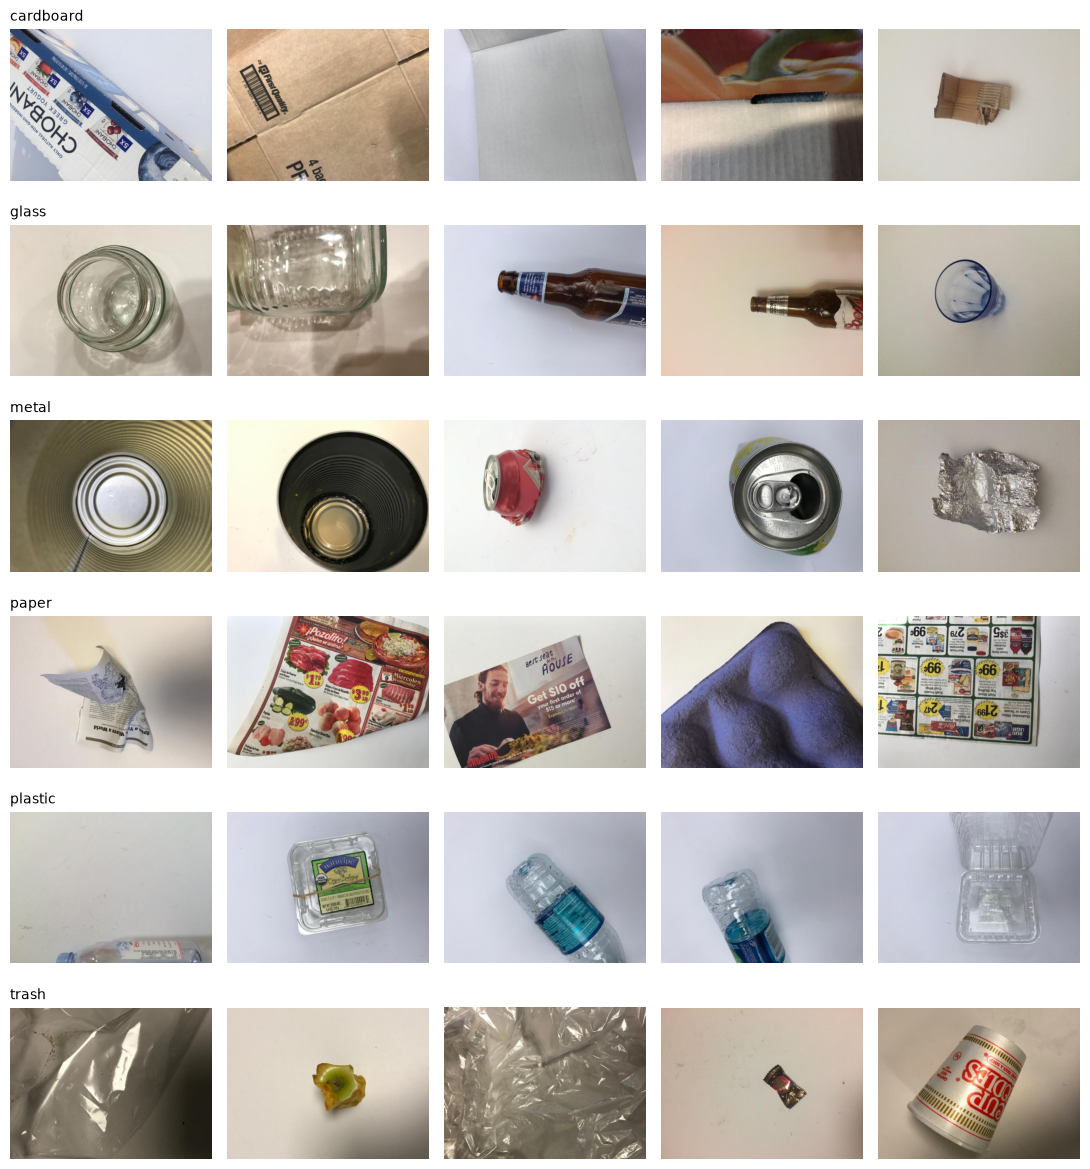

In [5]:
# Cellule 5 : 5 exemples par classe
n = 5
fig, axes = plt.subplots(len(classes), n, figsize=(2.2 * n, 2 * len(classes)))
for i, c in enumerate(classes):
    exemples = df[df["classe"] == c].sample(n, random_state=42)
    for j, p in enumerate(exemples["chemin"]):
        axes[i, j].imshow(Image.open(p))
        axes[i, j].axis("off")
    axes[i, 0].set_title(c, loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(FIG / "trashnet_exemples.png", dpi=80)
plt.show()

,mean,min,max
classe,,,
cardboard,162.0,74.0,253.0
glass,186.0,130.0,252.0
metal,178.0,83.0,242.0
paper,183.0,109.0,224.0
plastic,182.0,103.0,229.0
trash,177.0,91.0,222.0


Images avec un bord clair (> 180) : 56 %


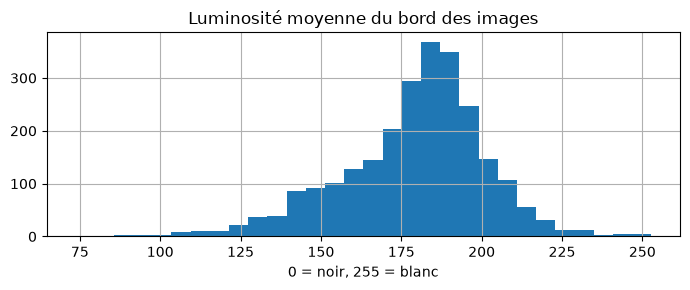

In [6]:
# Cellule 6 : le fond est-il blanc ? On mesure la luminosité du bord de chaque image (0 = noir, 255 = blanc)
def luminosite_bord(p, marge=20):
    a = np.asarray(Image.open(p).convert("L").resize((128, 96)), dtype=float)
    bord = np.concatenate([a[:marge // 4].ravel(), a[-marge // 4:].ravel(),
                           a[:, :marge // 4].ravel(), a[:, -marge // 4:].ravel()])
    return bord.mean()

df["lum_bord"] = [luminosite_bord(p) for p in df["chemin"]]
display(df.groupby("classe")["lum_bord"].describe()[["mean", "min", "max"]].round(0))
print(f"Images avec un bord clair (> 180) : {(df['lum_bord'] > 180).mean() * 100:.0f} %")

df["lum_bord"].hist(bins=30, figsize=(7, 3))
plt.title("Luminosité moyenne du bord des images")
plt.xlabel("0 = noir, 255 = blanc")
plt.tight_layout()
plt.savefig(FIG / "trashnet_fond.png", dpi=100)
plt.show()

,R,G,B
classe,,,
cardboard,170.0,149.0,128.0
glass,176.0,171.0,163.0
metal,165.0,157.0,152.0
paper,172.0,165.0,155.0
plastic,171.0,170.0,169.0
trash,179.0,166.0,149.0


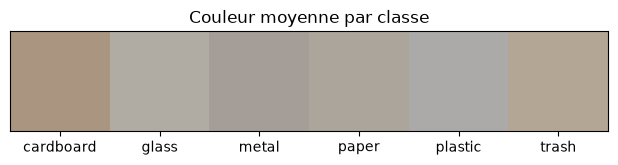

In [7]:
# Cellule 7 : couleur moyenne de chaque classe (le modèle pourrait tricher avec la couleur)
def couleur_moyenne(p):
    return np.asarray(Image.open(p).convert("RGB").resize((64, 48)), dtype=float).mean(axis=(0, 1))

couleurs = np.array([couleur_moyenne(p) for p in df["chemin"]])
df[["R", "G", "B"]] = couleurs
moy = df.groupby("classe")[["R", "G", "B"]].mean().round(0)
display(moy)

fig, ax = plt.subplots(figsize=(7, 1.5))
ax.imshow([moy.values / 255])
ax.set_xticks(range(len(moy)), moy.index)
ax.set_yticks([])
ax.set_title("Couleur moyenne par classe")
plt.tight_layout()
plt.show()

In [8]:
# Cellule 8 : doublons exacts (même fichier copié deux fois)
df["md5"] = [hashlib.md5(p.read_bytes()).hexdigest() for p in df["chemin"]]
doublons = df[df.duplicated("md5", keep=False)].sort_values("md5")
print(f"{len(doublons)} images concernées par des doublons exacts")
display(doublons[["classe", "fichier"]])

6 images concernées par des doublons exacts


,classe,fichier
421,glass,glass115.jpg
1305,metal,metal91.jpg
488,glass,glass176.jpg
1967,plastic,plastic152.jpg
724,glass,glass389.jpg
2167,plastic,plastic332.jpg


In [9]:
# Cellule 9 : résumé à recopier dans docs/eda-trashnet.md
print("Total images        :", len(df))
print("Images par classe   :", compte.to_dict())
print("Classe la plus rare :", compte.idxmin(), f"({compte.min()} images, {pourcent.min()} %)")
print("Tailles             :", df.groupby(['largeur', 'hauteur']).size().to_dict())
print("Bord clair (> 180)  :", f"{(df['lum_bord'] > 180).mean() * 100:.0f} %")
print("Doublons exacts     :", len(doublons))

Total images        : 2527
Images par classe   : {'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}
Classe la plus rare : trash (137 images, 5.4 %)
Tailles             : {(512, 384): 2527}
Bord clair (> 180)  : 56 %
Doublons exacts     : 6
